# Job Outcomes of Students

In this project, we will be exploring the jobs achieved by students that have graduated from American colleges. We will be able to filter data by their respecitve majors, gender, and number of students amongst other filters.

[The original data](https://www.census.gov/programs-surveys/acs/) was collected and released by the American Community Survey. It was cleaned and released by FiveThirtyEight, who released it on their [GitHub repo](https://github.com/fivethirtyeight/data/tree/master/college-majors).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

recent_grads = pd.read_csv('recent-grads.csv')
# We have imported the libraries we will be using in this project, and enabled us to visualise the plots in the Jupyter notebook
# We have read the file and have it ready for further processing

In [2]:
recent_grads.iloc[0]

Rank                                        1
Major_code                               2419
Major                   PETROLEUM ENGINEERING
Total                                    2339
Men                                      2057
Women                                     282
Major_category                    Engineering
ShareWomen                           0.120564
Sample_size                                36
Employed                                 1976
Full_time                                1849
Part_time                                 270
Full_time_year_round                     1207
Unemployed                                 37
Unemployment_rate                   0.0183805
Median                                 110000
P25th                                   95000
P75th                                  125000
College_jobs                             1534
Non_college_jobs                          364
Low_wage_jobs                             193
Name: 0, dtype: object

We can see all the labels present in the table. This is what each label represents:

- `Rank` - Rank by median earnings (the dataset is ordered by this column).
- `Major_code` - Major code.
- `Major` - Major description.
- `Major_category` - Category of major.
- `Total` - Total number of people with major.
- `Sample_size` - Sample size (unweighted) of full-time.
- `Men` - Male graduates.
- `Women` - Female graduates.
- `ShareWomen` - Women as share of total.
- `Employed` - Number employed.
- `Median` - Median salary of full-time, year-round workers.
- `Low_wage_jobs` - Number in low-wage service jobs.
- `Full_time` - Number employed 35 hours or more.
- `Part_time` - Number employed less than 35 hours.

We can use `.head()` and `.tail()`, to get familiar with the data. As well as using `.describe()` to get a general idea of the data.

In [3]:
recent_grads.head(2)

,Rank,Major_code,Major,Total,Men,Women,Major_category,ShareWomen,Sample_size,Employed,...,Part_time,Full_time_year_round,Unemployed,Unemployment_rate,Median,P25th,P75th,College_jobs,Non_college_jobs,Low_wage_jobs
0,1,2419,PETROLEUM ENGINEERING,2339.0,2057.0,282.0,Engineering,0.120564,36,1976,...,270,1207,37,0.018381,110000,95000,125000,1534,364,193
1,2,2416,MINING AND MINERAL ENGINEERING,756.0,679.0,77.0,Engineering,0.101852,7,640,...,170,388,85,0.117241,75000,55000,90000,350,257,50


In [4]:
recent_grads.tail(2)

,Rank,Major_code,Major,Total,Men,Women,Major_category,ShareWomen,Sample_size,Employed,...,Part_time,Full_time_year_round,Unemployed,Unemployment_rate,Median,P25th,P75th,College_jobs,Non_college_jobs,Low_wage_jobs
171,172,5203,COUNSELING PSYCHOLOGY,4626.0,931.0,3695.0,Psychology & Social Work,0.798746,21,3777,...,965,2738,214,0.053621,23400,19200,26000,2403,1245,308
172,173,3501,LIBRARY SCIENCE,1098.0,134.0,964.0,Education,0.877960,2,742,...,237,410,87,0.104946,22000,20000,22000,288,338,192


In [5]:
recent_grads.describe()

,Rank,Major_code,Total,Men,Women,ShareWomen,Sample_size,Employed,Full_time,Part_time,Full_time_year_round,Unemployed,Unemployment_rate,Median,P25th,P75th,College_jobs,Non_college_jobs,Low_wage_jobs
count,173.000000,173.000000,172.000000,172.000000,172.000000,172.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000
mean,87.000000,3879.815029,39370.081395,16723.406977,22646.674419,0.522223,356.080925,31192.763006,26029.306358,8832.398844,19694.427746,2416.329480,0.068191,40151.445087,29501.445087,51494.219653,12322.635838,13284.497110,3859.017341
std,50.084928,1687.753140,63483.491009,28122.433474,41057.330740,0.231205,618.361022,50675.002241,42869.655092,14648.179473,33160.941514,4112.803148,0.030331,11470.181802,9166.005235,14906.279740,21299.868863,23789.655363,6944.998579
min,1.000000,1100.000000,124.000000,119.000000,0.000000,0.000000,2.000000,0.000000,111.000000,0.000000,111.000000,0.000000,0.000000,22000.000000,18500.000000,22000.000000,0.000000,0.000000,0.000000
25%,44.000000,2403.000000,4549.750000,2177.500000,1778.250000,0.336026,39.000000,3608.000000,3154.000000,1030.000000,2453.000000,304.000000,0.050306,33000.000000,24000.000000,42000.000000,1675.000000,1591.000000,340.000000
50%,87.000000,3608.000000,15104.000000,5434.000000,8386.500000,0.534024,130.000000,11797.000000,10048.000000,3299.000000,7413.000000,893.000000,0.067961,36000.000000,27000.000000,47000.000000,4390.000000,4595.000000,1231.000000
75%,130.000000,5503.000000,38909.750000,14631.000000,22553.750000,0.703299,338.000000,31433.000000,25147.000000,9948.000000,16891.000000,2393.000000,0.087557,45000.000000,33000.000000,60000.000000,14444.000000,11783.000000,3466.000000
max,173.000000,6403.000000,393735.000000,173809.000000,307087.000000,0.968954,4212.000000,307933.000000,251540.000000,115172.000000,199897.000000,28169.000000,0.177226,110000.000000,95000.000000,125000.000000,151643.000000,148395.000000,48207.000000


As matplotlib expects we are using columns of data with equal length, we must remove any entries with missing values.

In [6]:
raw_data_count = recent_grads.count()
# print(raw_data_count)
# We can see that there is a few missing values in the columns designated Total, Men, Women, and ShareWomen

In [7]:
recent_grads = recent_grads.dropna()
cleaned_data_count = recent_grads.count()
# print(cleaned_data_count)
# We can see that one row of data was removed, and now all columns are at 172 length

### Scatter plots of data for preliminary analysis

The scatter plots are created using Pandas.

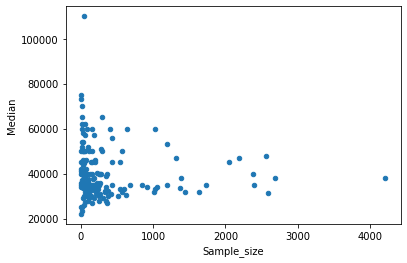

In [8]:
recent_grads.plot(x='Sample_size', y='Median', kind='scatter')

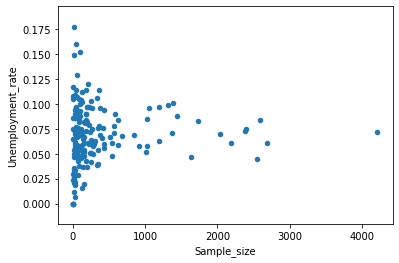

In [9]:
recent_grads.plot(x='Sample_size', y='Unemployment_rate', kind='scatter')

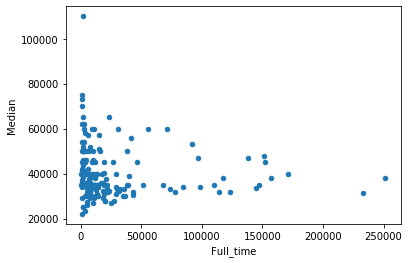

In [10]:
recent_grads.plot(x='Full_time', y='Median', kind='scatter')

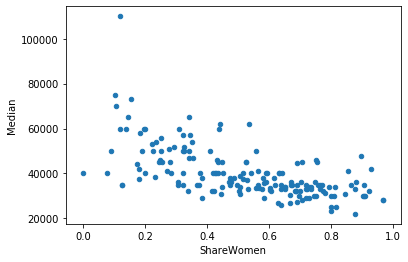

In [11]:
recent_grads.plot(x='ShareWomen', y='Median', kind='scatter')

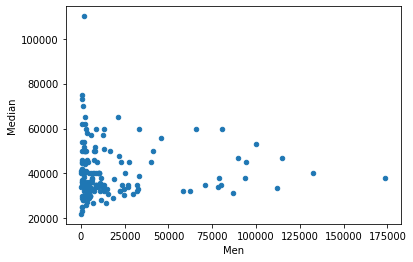

In [12]:
recent_grads.plot(x='Men', y='Median', kind='scatter')

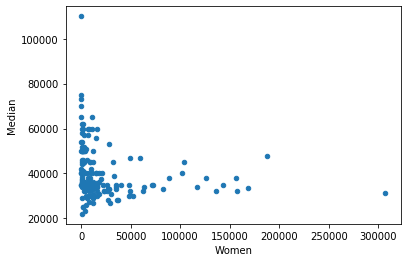

In [13]:
recent_grads.plot(x='Women', y='Median', kind='scatter')

Looking at the data, we can answer some questions from a prelimiary view:

- Do students in more popular majors make more money?

From the look at the graph of Median and Sample_size, we can see that courses with the highest median wage, are courses with smaller sample sizes. The most popular course, has a median wage of approx 40,000 USD, whereas the highest paid major appears to have a small sample size, but with wages of about 115,000 USD.

- Do students that majored in subjects that were majority female make more money?

There appears to be a negative trend, whereby, as the proportion of female students increases, the median wage decreases. This can be seen by looking at the graph comparing ShareWomen and Median.

- Is there any link between the number of full-time employees and median salary?

The graph showing Full_time against Median shows a very similar trend to the graph showing Median and Sample_size. It appears therefore, the difference between full time and part time is not as severe when it comes to affecting median salary. However, there is a negative trend, suggesting, the more full time, the less the median income.

### Histograms of Data

The scatter plots are created using Matplotlib.

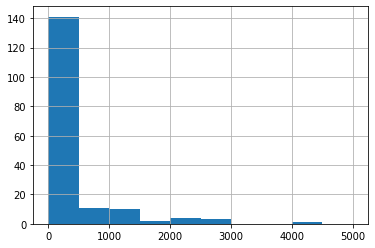

In [14]:
recent_grads['Sample_size'].hist(bins=10, range=(0,5000))

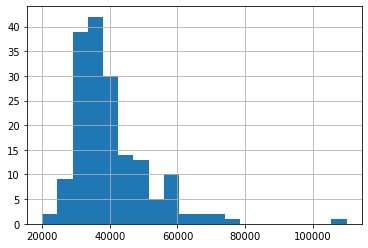

In [15]:
recent_grads['Median'].hist(bins=20, range=(20000,110000))

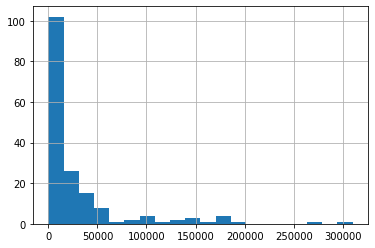

In [16]:
recent_grads['Employed'].hist(bins=20, range=(0,310000))

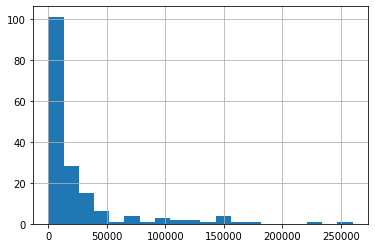

In [17]:
recent_grads['Full_time'].hist(bins=20, range=(0,260000))

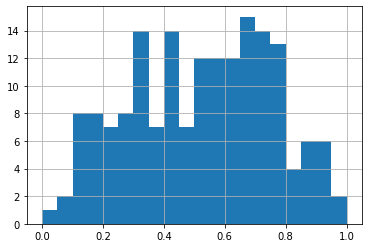

In [18]:
recent_grads['ShareWomen'].hist(bins=20, range=(0,1))

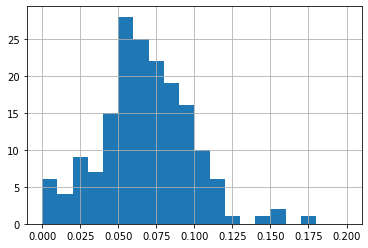

In [19]:
recent_grads['Unemployment_rate'].hist(bins=20, range=(0,0.2))

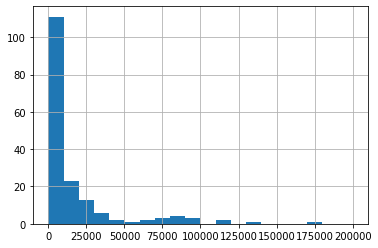

In [20]:
recent_grads['Men'].hist(bins=20, range=(0,200000))

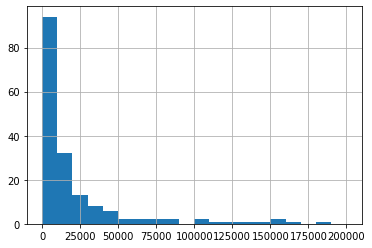

In [21]:
recent_grads['Women'].hist(bins=20, range=(0,200000))

### Scatter Matrix Plot
A scatter matrix plot combines both scatter plots and histograms into one grid of plots and allows us to explore potential relationships and distributions simultaneously.

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x000002D4310B6548>,
      dtype=object)

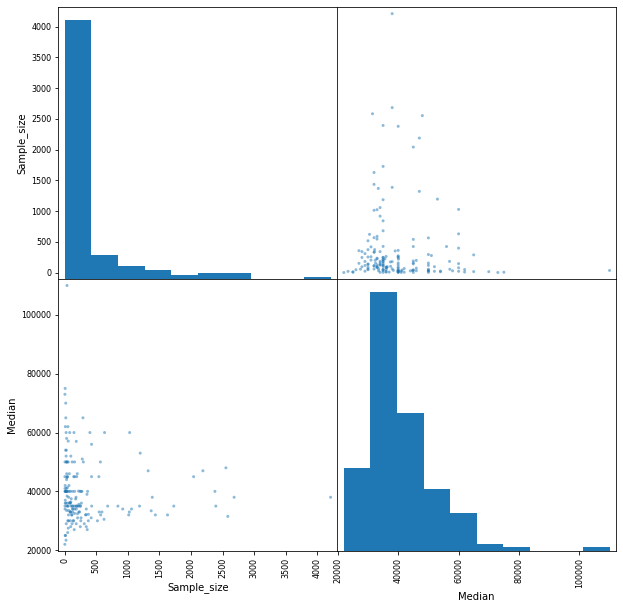

In [22]:
from pandas.plotting import scatter_matrix

# We need to import this function in order to be able to use it
scatter_matrix(recent_grads[['Sample_size', 'Median']], figsize=(10,10))

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x000002D42FBBAE48>,
      dtype=object)

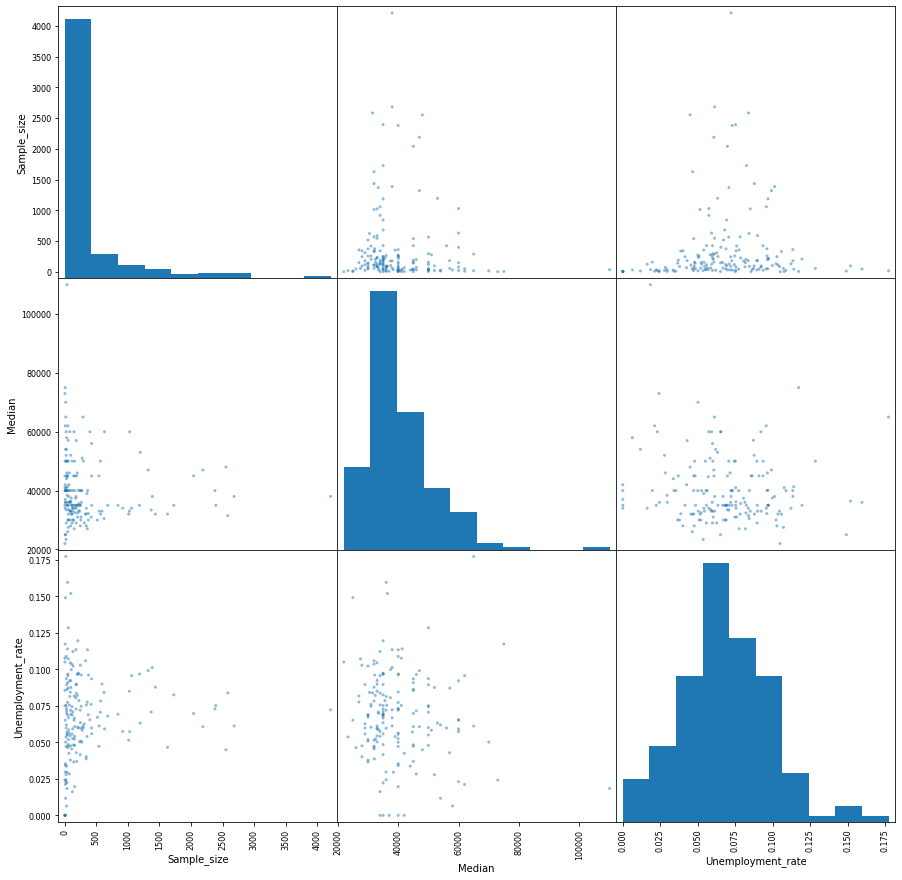

In [23]:
scatter_matrix(recent_grads[['Sample_size', 'Median', 'Unemployment_rate']], figsize=(15,15))

Let us revisit our questions:

- Do students in more popular majors make more money?

From the look at the graph of Median and Sample_size, we can see that courses with the highest median wage, are courses with smaller sample sizes. The most popular course, has a median wage of approx 40,000 USD, whereas the highest paid major appears to have a small sample size, but with wages of about 115,000 USD.

(This analysis is supported by the matrix graphs)

We also notice that the more popular the course is, the more likely it is to have a higher unemployment rate.

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x000002D431441248>,
      dtype=object)

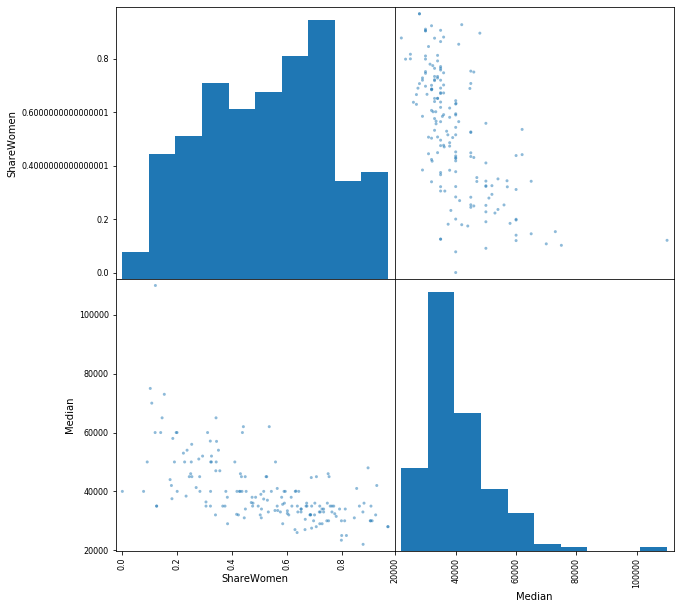

In [24]:
scatter_matrix(recent_grads[['ShareWomen', 'Median']], figsize=(10,10))

- Do students that majored in subjects that were majority female make more money?

There appears to be a negative trend, whereby, as the proportion of female students increases, the median wage decreases. This can be seen by looking at the graph comparing ShareWomen and Median.

(This is supported by the new graph)

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x000002D4318F79C8>,
      dtype=object)

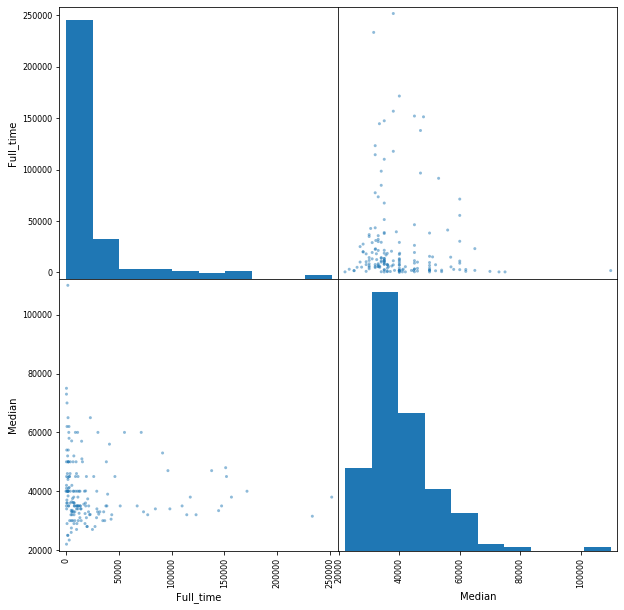

In [25]:
scatter_matrix(recent_grads[['Full_time', 'Median']], figsize=(10,10))

- Is there any link between the number of full-time employees and median salary?

The graph showing Full_time against Median shows a very similar trend to the graph showing Median and Sample_size. It appears therefore, the difference between full time and part time is not as severe when it comes to affecting median salary. However, there is a negative trend, suggesting, the more full time, the less the median income.

(This is supported by the new graph)

We can see clearly in the new graph, the higher paid roles have fewer numbers of full-tume employees.

### Analysis using Bar-Plots from Pandas

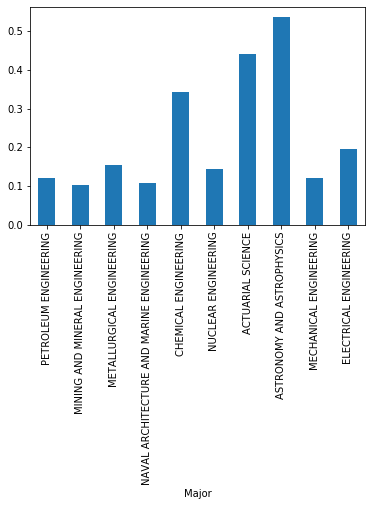

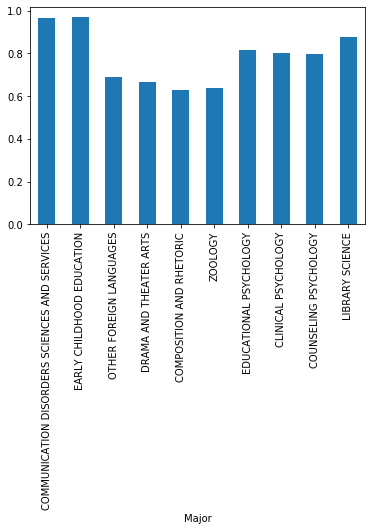

In [26]:
recent_grads[:10].plot.bar(x='Major', y='ShareWomen', legend=False)
recent_grads[-10:].plot.bar(x='Major', y='ShareWomen', legend=False)

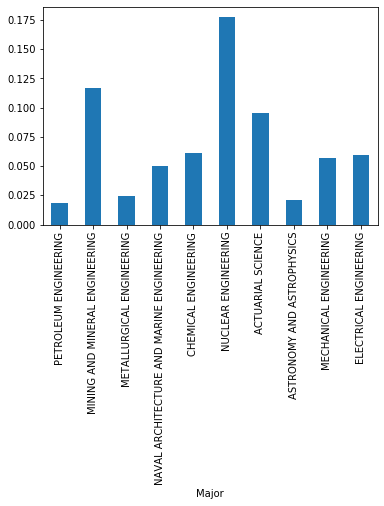

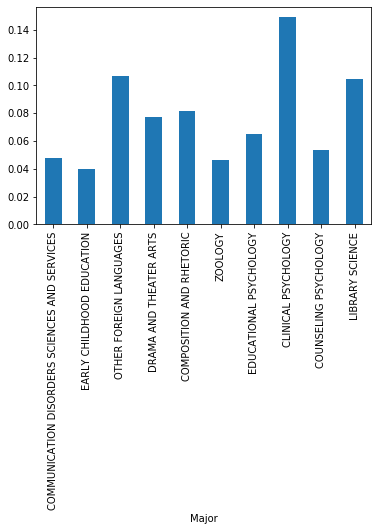

In [27]:
recent_grads[:10].plot.bar(x='Major', y='Unemployment_rate', legend=False)
recent_grads[-10:].plot.bar(x='Major', y='Unemployment_rate', legend=False)